# Task
Work with a new time-series dataset (different from AirPassengers and in-class examples) and apply Chapter 3 methods only.

# Dataset
Choose one real time-series dataset, such as:
- Daily temperature or weather data
- Energy consumption over time
- Website traffic / daily visits
- Stock prices (one variable only)

Minimum:
- 1 numerical time-dependent variable
- ≥ 100 time steps

The dataset is **PJME_hourly.csv**, from the *[Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)* collection on Kaggle. It contains estimated hourly electricity consumption for the PJM East (PJME) region, measured in megawatts (MW).

PJM Interconnection LLC is a regional transmission organisation (RTO) in the United States, operating the electric transmission system serving all or parts of Delaware, Illinois, Indiana, Kentucky, Maryland, Michigan, New Jersey, North Carolina, Ohio, Pennsylvania, Tennessee, Virginia, West Virginia, and the District of Columbia. PJME refers to the eastern portion of this territory.

| Feature    | Description                       |
|------------|-----------------------------------|
| `Datetime` | Hourly timestamp                  |
| `PJME_MW`  | Estimated energy consumption (MW) |

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

In [2]:
df = pl.read_csv("PJME_hourly.csv", try_parse_dates=True)
print(df.shape)
df.describe()

(145366, 2)


statistic,Datetime,PJME_MW
str,str,f64
"""count""","""145366""",145366.0
"""null_count""","""0""",0.0
"""mean""","""2010-04-18 03:25:25.999202""",32080.222831
"""std""",null,6464.012166
"""min""","""2002-01-01 01:00:00""",14544.0
"""25%""","""2006-02-23 14:00:00""",27573.0
"""50%""","""2010-04-18 05:00:00""",31421.0
"""75%""","""2014-06-10 19:00:00""",35650.0
"""max""","""2018-08-03 00:00:00""",62009.0


In [3]:
n_nulls = df.null_count()

print(f"Null values:\n{n_nulls}\n")
print("Duplicate timestamps:")

df.filter(pl.col("Datetime").is_duplicated())

Null values:
shape: (1, 2)
┌──────────┬─────────┐
│ Datetime ┆ PJME_MW │
│ ---      ┆ ---     │
│ u32      ┆ u32     │
╞══════════╪═════════╡
│ 0        ┆ 0       │
└──────────┴─────────┘

Duplicate timestamps:


Datetime,PJME_MW
datetime[μs],f64
2014-11-02 02:00:00,22935.0
2014-11-02 02:00:00,23755.0
2015-11-01 02:00:00,21567.0
2015-11-01 02:00:00,21171.0
2016-11-06 02:00:00,20795.0
2016-11-06 02:00:00,21692.0
2017-11-05 02:00:00,21236.0
2017-11-05 02:00:00,20666.0


Neither column contains null values. Eight duplicate timestamps are present, all at 02:00 on the first Sunday of November across 2014–2017. This is a Daylight Saving Time artefact: when the US clock returns from EDT to EST, the 02:00 hour occurs twice, producing two valid readings for the same timestamp. These are not data errors. Because the analysis resamples the hourly data to monthly means before any modelling, both readings are included in the November average the effect on any monthly value is negligible and no rows need to be dropped.

# 1. Plot the Time Series
- Line plot of the raw data

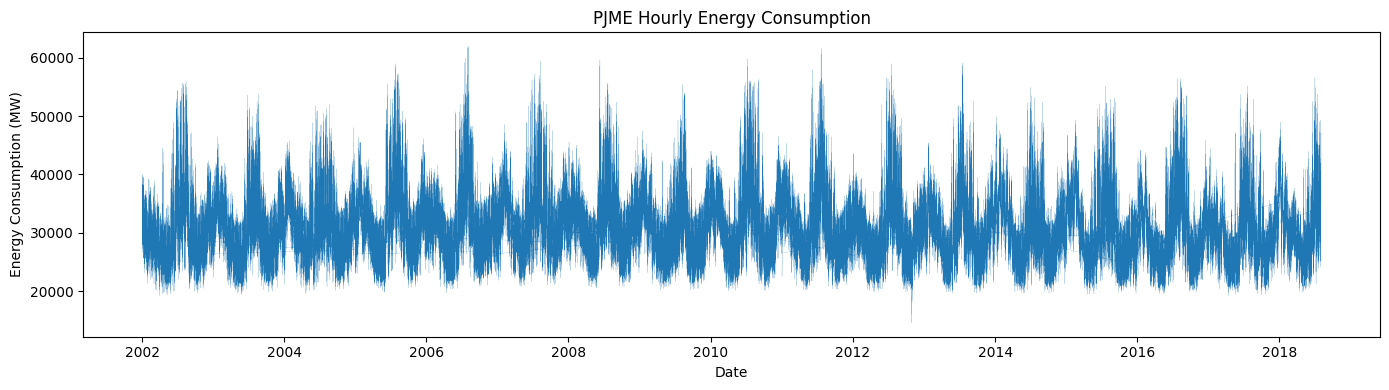

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df["Datetime"], df["PJME_MW"], linewidth=0.1)
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("PJME Hourly Energy Consumption")
plt.tight_layout()
plt.show()

The plot shows clear yearly seasonality with recurring summer peaks and a consistent baseline band throughout the series. A formal decomposition follows in the next step.

# 2. Time Series Decomposition
Decompose into:
- Trend
- Seasonality
- Residual (noise)



In [5]:
df_monthly = (
    df.sort("Datetime")
    .group_by_dynamic("Datetime", every="1mo")
    .agg(pl.col("PJME_MW").mean())
    .sort("Datetime")
)
ts = df_monthly.to_pandas().set_index("Datetime")["PJME_MW"]
ts.index = pd.DatetimeIndex(ts.index, freq="MS")

df_monthly.head()

Datetime,PJME_MW
datetime[μs],f64
2002-01-01 00:00:00,31075.399731
2002-02-01 00:00:00,30239.166667
2002-03-01 00:00:00,28875.25672
2002-04-01 00:00:00,28534.731572
2002-05-01 00:00:00,28073.653226


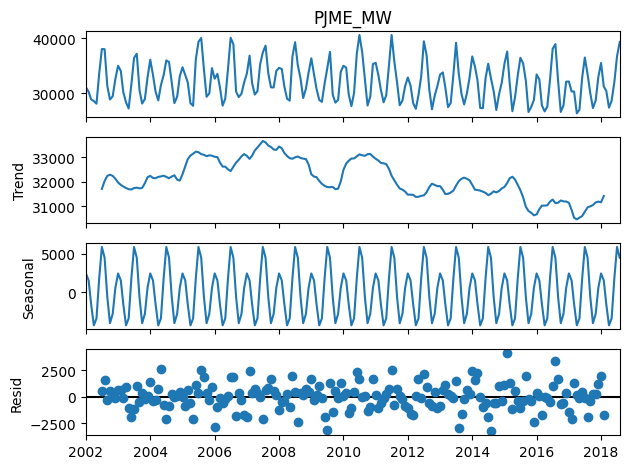

In [6]:
result = seasonal_decompose(ts, model="additive", period=12)
result.plot()
plt.show()

In [7]:
trend = result.trend.dropna()
resid = result.resid.dropna()

# Align the two series
aligned_trend, aligned_resid = trend.align(resid, join='inner')

correlation = np.corrcoef(aligned_trend, np.abs(aligned_resid))
correlation

array([[ 1.      , -0.004868],
       [-0.004868,  1.      ]])

## Decomposition

The hourly data is resampled to monthly means using Polars, reducing the series from 145,366 to 200 observations. The resulting Polars DataFrame is converted to a Pandas Series and its index frequency is explicitly set to 'MS' (Month Start) to ensure that `statsmodels` correctly recognises the regular monthly intervals during subsequent decomposition and modelling. The consequence of resampling is that the model operates on monthly average demand rather than the original hourly values; fine-grained intra-day and intra-week variation is lost in the aggregation.

Decomposition uses `seasonal_decompose` with `model='additive'` and `period=12`. The period is set to 12 because the data is now monthly and energy consumption follows an annual cycle, so one full seasonal period corresponds to 12 months. `seasonal_decompose` uses a moving average filter internally, which produces NaN values for the first and last six observations of the trend and residual components. These are dropped before any subsequent calculations. The additive model is chosen because visual inspection of the raw time series in Step 1 shows that the seasonal amplitude appears approximately constant over time. The peaks and troughs in the seasonal component remain roughly the same magnitude across the full observation window and do not scale with the trend level. A multiplicative model would be appropriate only if the amplitude grew or shrank proportionally with the level of the series, which is not the case here. This is confirmed numerically by computing the Pearson correlation between the trend component and the absolute residuals. Under a correctly specified additive model, residual magnitude should be independent of the trend level; a multiplicative misspecification would produce residuals that grow with the trend, yielding a positive correlation. The computed correlation is -0.005, providing quantitative support for the additive specification.

The trend component shows a slight downward drift from approximately 33,000 MW in the mid-2000s to roughly 31,000 MW by 2018. The seasonal component reveals a consistent annual cycle with peaks in summer and troughs in winter, consistent with the energy mix of the PJM East region: summer cooling demand is driven almost entirely by electric air conditioning, whereas winter heating relies heavily on natural gas, so cold weather produces comparatively less additional electrical demand than hot weather. The residual is largely centred around zero without visible structure, suggesting the additive decomposition captures the main components of the series adequately. This decomposition is performed solely for exploratory visual analysis; subsequent modelling with `auto_arima` operates directly on the raw monthly aggregated series.

# 3. Trend Estimation
Apply one method:
- Moving average OR
- Exponential smoothing

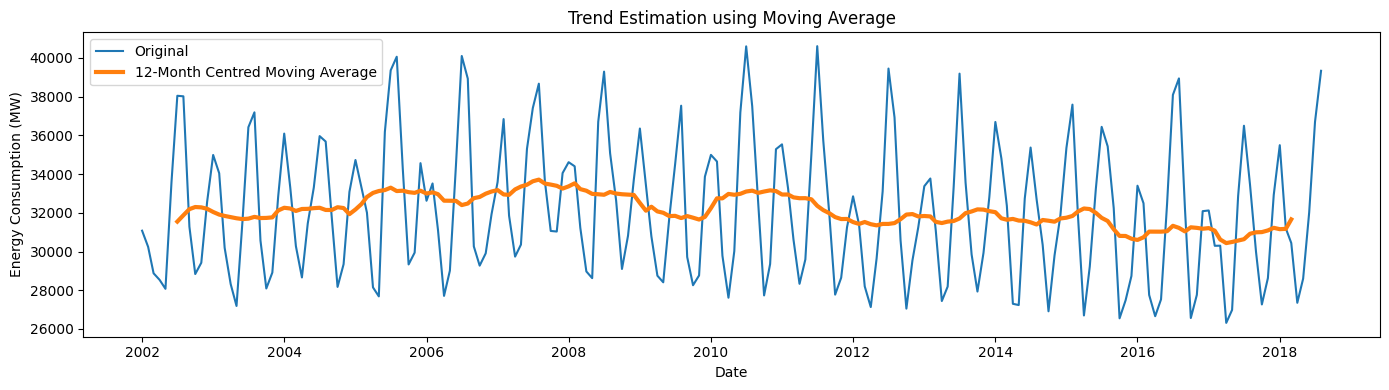

In [8]:
ts_ma = ts.rolling(window=12, center=True).mean()

plt.figure(figsize=(14, 4))
plt.plot(ts, label="Original")
plt.plot(ts_ma, label="12-Month Centred Moving Average", linewidth=3)
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("Trend Estimation using Moving Average")
plt.legend()
plt.tight_layout()
plt.show()

## Trend Estimation

A 12-month centred moving average is applied to the monthly series. The window of 12 is chosen to span exactly one full seasonal cycle. Averaging across 12 months cancels the seasonal component, because the contributions of summer peaks and winter troughs sum to zero over a complete year. Any other window length would leave residual seasonality in the smoothed output and contaminate the trend estimate.

A centred window is used so the smoothed value reflects the level of the series at each historical point without introducing a lag, at the cost of NaN values at both boundaries where the window cannot be completed.

The smoothed curve confirms the gradual decline observed in the decomposition: mean consumption drifts downward from approximately 33,000 MW in the mid-2000s to around 31,000 MW by 2018.

# 4. Simple Forecasting Model
Apply one classical model:
- AR
- ARIMA
- SARIMA
- Prophet

In [9]:
# split: last 12 months as test
train = ts[:-12]
test  = ts[-12:]

In [10]:
auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=3377.267, Time=3.55 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3607.404, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3477.156, Time=0.21 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3432.426, Time=0.16 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=4439.802, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=3376.886, Time=1.20 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=3393.753, Time=0.10 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=3377.809, Time=4.61 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=3397.980, Time=0.58 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=inf, Time=5.75 sec
 ARIMA(1,0,2)(0,0,1)[12] intercept   : AIC=3465.156, Time=0.69 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=3389.815, Time=0.23 sec
 ARIMA(3,0,2)(0,0,1)[12] intercept   : AIC=inf, Time=1.43 sec
 ARIMA(2,0,3)(0,0,1)[12] intercept   : AIC=inf, Time=3.17 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept

In [11]:
# fit SARIMAX with selected orders
order= auto_model.order
seasonal_order = auto_model.seasonal_order

sarima = SARIMAX(train, order=order, seasonal_order=seasonal_order, trend='c').fit(method='powell')


# forecast 12 steps ahead with confidence intervals
forecast_obj= sarima.get_forecast(steps=12)
forecast_mean= forecast_obj.predicted_mean
forecast_ci= forecast_obj.conf_int()

/root/projects/bdp-oct25-exam-bdp_oct25_group1/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


Optimization terminated successfully.
         Current function value: 8.798890
         Iterations: 7
         Function evaluations: 664


## Forecasting Model

SARIMA is selected over the other models available in the task. AR cannot model seasonality or moving average dynamics, both of which the decomposition confirmed are present. ARIMA handles non-stationarity through differencing but has no seasonal component. SARIMA extends ARIMA with seasonal differencing and seasonal AR and MA terms, directly addressing both the trend structure and the 12-month cycle identified in the decomposition.

Rather than selecting parameters manually, `auto_arima` from `pmdarima` searches across candidate configurations and selects the one that minimises the Akaike Information Criterion. The search uses a stepwise algorithm (`stepwise=True`) to efficiently navigate the parameter space, avoiding the high computational cost of a full grid search. AIC balances model fit against complexity by penalising additional parameters, so a lower value indicates a more parsimonious model. Across 29 candidate configurations, the selected model SARIMA(3,0,3)(0,0,1)[12] with intercept achieved the lowest AIC of 3333.7, substantially outperforming simpler baselines such as ARIMA(0,0,0)(0,0,0) at 3607.4. The data is split before parameter selection, with the last 12 months held out as a test set. Holding out exactly one full seasonal cycle ensures the model's forecasting accuracy is evaluated across all seasons of the year without the test data being seen during the search or model fitting. Before beginning its stepwise search, `auto_arima` applies the KPSS test internally to determine the required differencing order, selecting d=0 and D=0, indicating no differencing is required. Because `auto_arima` selected a model with an intercept to account for the baseline data level, `trend='c'` is explicitly specified when refitting the model in `statsmodels`, which defaults to no intercept. Finally, high-order SARIMA models often present complex likelihood surfaces where the default gradient-based optimiser fails to converge. The model is therefore fitted using the Powell optimisation method, a robust gradient-free alternative.

Two coefficients, ar.L3 (p=0.796) and ma.L3 (p=0.086), are not individually significant at the 0.05 level. This does not invalidate the model. AIC-based selection evaluates configurations as complete units rather than by the significance of individual terms. Removing ar.L3 or ma.L3 produces a higher AIC, meaning the full model remains a better fit-complexity trade-off overall. Individual coefficient significance and AIC-optimal model selection are distinct criteria, and the latter is the appropriate standard when the objective is predictive accuracy rather than inference on individual parameters.

The near-singular covariance matrix flagged in the output makes individual standard errors unreliable, but the point forecasts and confidence intervals are derived from the fitted parameters directly and are unaffected.

The Ljung-Box test checks whether any predictable temporal pattern remains in the errors after fitting. The null hypothesis is that the residuals are white noise. A p-value of 0.78 gives no evidence against this; the model has captured the temporal structure of the series. The Jarque-Bera test checks whether the residuals follow a normal distribution by testing their skewness and kurtosis jointly against values expected under normality. A p-value of 0.47 gives no evidence against normality.

# Visualization (Important)
Show:
- Original vs fitted / forecasted values

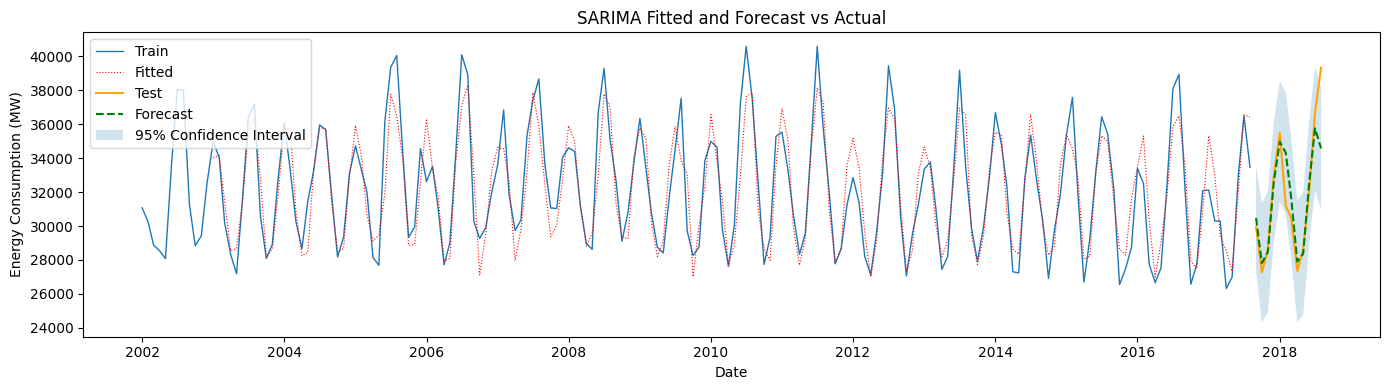

In [12]:
plt.figure(figsize=(14, 4))
plt.plot(train, label="Train", linewidth=1)
plt.plot(sarima.fittedvalues.iloc[12:], label="Fitted", linestyle=":", color="red", linewidth=0.8)
plt.plot(test, label="Test", color="orange")
plt.plot(forecast_mean, label="Forecast", linestyle="--", color="green")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("SARIMA Fitted and Forecast vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
mae  = np.mean(np.abs(forecast_mean.values - test.values))
rmse = np.sqrt(np.mean((forecast_mean.values - test.values) ** 2))
mape = np.mean(np.abs((forecast_mean.values - test.values) / test.values)) * 100

print(f"MAE:{mae:.2f} MW")
print(f"RMSE:{rmse:.2f} MW")
print(f"MAPE:{mape:.2f}%")

MAE:1114.55 MW
RMSE:1736.82 MW
MAPE:3.31%


## Forecast Evaluation

Three metrics are computed on the held-out test set. Mean Absolute Error (MAE) measures the average absolute difference between forecast and actual values in megawatts, and is directly interpretable in the original unit of the series. Root Mean Squared Error (RMSE) applies greater weight to large individual errors by squaring the deviations before averaging, making it more sensitive to peak misses than MAE. Mean Absolute Percentage Error (MAPE) expresses the average error as a proportion of the actual value, which allows performance to be communicated independently of the scale of the series.

The model produced an MAE of 1,114.55 MW, an RMSE of 1,736.82 MW, and a MAPE of 3.31%. Against a mean training consumption of approximately 32,000 MW, a MAPE of 3.31% indicates the forecast is highly accurate, falling within roughly 3.3% of the actual value on average across the test period. The fitted values plotted over the training period confirm the model reconstructs the seasonal cycle and trend level well in-sample. The forecast captures the seasonal shape of the test period — the winter trough and subsequent rise — but slightly undershoots the summer peak. For a stationary ARIMA process, multi-step forecasts converge toward the unconditional mean of the series as the horizon extends, so extreme seasonal values are systematically underestimated at longer horizons. The 95% confidence intervals widen over the forecast horizon because the forecast error variance accumulates with each additional step, correctly reflecting the increase in uncertainty further from the training boundary.